In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from lightgbm import LGBMRegressor
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV

In [2]:
df=pd.read_csv('/Users/omartharwat/Desktop/Eplison/Final_project/cleaned_amazon_sales.csv')

In [3]:
df = df[df['Amount'] != 0]

In [4]:
df.isna().sum()

Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
SKU                        0
Category                   0
Size                       0
Courier Status             0
Qty                        0
Amount                     0
ship-city                  0
ship-state                32
B2B                        0
SKU_freq                   0
year                       0
month                      0
day                        0
Amount_missing             0
weekday                    0
is_weekend                 0
Amount_log                 0
ship_city_grouped          0
ship_city_grouped_freq     0
dtype: int64

In [5]:
df = df.dropna()

In [6]:
bad_status = [
    'Cancelled',
    'Shipped - Returned to Seller',
    'Shipped - Returning to Seller',
    'Shipped - Damaged',
    'Shipped - Lost in Transit'
]

df = df[~df['Status'].isin(bad_status)]

In [7]:
status_map = {
    "Shipped": "Shipped",
    "Shipped - Delivered to Buyer": "Delivered",
    "Shipped - Picked Up": "In_Transit",
    "Pending": "Pending",
    "Pending - Waiting for Pick Up": "Pending",
    "Shipped - Out for Delivery": "In_Transit",
    "Shipped - Rejected by Buyer": "Other",
    "Shipping": "In_Transit"
}

df["Status_grouped"] = df["Status"].map(status_map).fillna("Other")

In [8]:
df["Category_freq"] = df["Category"].map(df["Category"].value_counts())

In [10]:
df.head()

,Date,Status,Fulfilment,Sales Channel,ship-service-level,SKU,Category,Size,Courier Status,Qty,...,month,day,Amount_missing,weekday,is_weekend,Amount_log,ship_city_grouped,ship_city_grouped_freq,Status_grouped,Category_freq
1,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781-KR-XXXL,kurta,3XL,Shipped,1,...,4,30,0,5,1,6.008813,BENGALURU,10666,Delivered,41284
2,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371-KR-XL,kurta,XL,Shipped,1,...,4,30,0,5,1,5.799093,NAVI MUMBAI,1254,Shipped,41284
4,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671-TU-XXXL,Top,3XL,Shipped,1,...,4,30,0,5,1,6.354370,CHENNAI,5226,Shipped,9114
5,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,SET264-KR-NP-XL,Set,XL,Shipped,1,...,4,30,0,5,1,6.715383,GHAZIABAD,1301,Shipped,37656
6,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,J0095-SET-L,Set,L,Shipped,1,...,4,30,0,5,1,6.483107,Other,70164,Shipped,37656


In [11]:
# Drop raw SKU after extracting useful features
df.drop(columns=['SKU','Amount_missing','Amount_log','year'], inplace=True)

In [12]:
y = np.log1p(df['Amount'])

In [13]:
# Frequency encodings

df['Category_freq'] = (
    df['Category']
    .map(df['Category'].value_counts())
)

df['state_freq'] = (
    df['ship-state']
    .map(df['ship-state'].value_counts())
)

df['size_freq'] = (
    df['Size']
    .map(df['Size'].value_counts())
)

# Category + state frequency
df['cat_state'] = (
    df['Category'].astype(str)
    + "_"
    + df['ship-state'].astype(str)
)

df['cat_state_freq'] = (
    df['cat_state']
    .map(df['cat_state'].value_counts())
)

In [14]:
cat_cols = [
    'Category',
    'Size'
]

num_cols = [
    'SKU_freq',
    'Category_freq',
    'size_freq'
]

In [15]:
X = df[cat_cols + num_cols]
y = df['Amount']

 # Pipline and Transformation

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        ), 
        (
            "num",
            "passthrough",
            num_cols
        )
    ]
)

 # CatBoost Model 

In [131]:

pip = Pipeline([
    ('preprocessor', preprocessor),
    ('model', CatBoostRegressor(
        loss_function='RMSE',
        verbose=0,
        random_state=42,
        allow_writing_files=False
    ))
])

param_dist = {
    'model__iterations': [800,1000,1200],
    'model__depth': [8, 9],
    'model__learning_rate': [0.03, 0.05],
    'model__l2_leaf_reg': [4, 5, 6]
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pip,
    param_distributions=param_dist,
    n_iter=10,
    scoring='r2',
    cv=cv,
    n_jobs=1,
    random_state=42,
    verbose=1
)

search.fit(X, y)

print("Best Params:", search.best_params_)
print("Best CV R2:", search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'model__learning_rate': 0.05, 'model__l2_leaf_reg': 4, 'model__iterations': 1200, 'model__depth': 9}
Best CV R2: 0.6888198743912184


In [132]:
best_model = search.best_estimator_

y_pred = best_model.predict(X)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("Best CV R2:", search.best_score_)
print("R2 on full data:", r2_score(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))

Best CV R2: 0.6888198743912184
R2 on full data: 0.7160811159809413
MAE: 84.15005722834283
RMSE: 119.26298518792441


# feature selection and importance in Cat_model

In [133]:
feature_importance = best_model.named_steps['model'].feature_importances_

feature_names = (
    best_model.named_steps['preprocessor']
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print(importance_df.head(30))

                        feature  importance
23           num__Category_freq   31.040261
22                num__SKU_freq   27.449652
8           cat__Category_kurta   15.279004
24               num__size_freq    6.400284
5             cat__Category_Set    4.583738
20                   num__month    2.456581
17                 cat__Size_XL    1.458186
14                  cat__Size_L    1.177919
15                  cat__Size_M    1.085802
9                 cat__Size_3XL    0.992539
19                cat__Size_XXL    0.974943
16                  cat__Size_S    0.967654
6             cat__Category_Top    0.964373
3    cat__Category_Ethnic Dress    0.904034
26          num__cat_state_freq    0.895178
7   cat__Category_Western Dress    0.856663
25              num__state_freq    0.786996
18                 cat__Size_XS    0.766004
21                 num__weekday    0.708106
0          cat__Category_Blouse    0.095845
12                cat__Size_6XL    0.063063
1          cat__Category_Bottom 

In [51]:
import joblib
pip.fit(X, y)
joblib.dump(pip, "amount_pipeline.joblib")
print("Model saved as amount_pipeline.joblib")

Model saved as amount_pipeline.joblib


 # XGboost Model

In [17]:
from sklearn.model_selection import cross_val_score, KFold
pip_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    ))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pip_2, X, y, cv=cv, scoring='r2', n_jobs=1)
print(scores.mean())

0.6749155261438631


 # CrossValidation and Tunining 

In [18]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_pip = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1
    ))
])

param_dist = {
    "model__n_estimators": [500, 600, 700, 800],
    "model__max_depth": [5, 6, 7],
    "model__learning_rate": [0.03, 0.05, 0.07],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3],
    "model__reg_alpha": [0, 0.1, 0.5],
    "model__reg_lambda": [1, 2, 5]
}

search = RandomizedSearchCV(
    estimator=xgb_pip,
    param_distributions=param_dist,
    n_iter=15,
    scoring="r2",
    cv=cv,
    n_jobs=1,
    random_state=42,
    verbose=1
)

search.fit(X, y)

print("Best Params:", search.best_params_)
print("Best CV R2:", search.best_score_)

best_xgb = search.best_estimator_

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Params: {'model__subsample': 1.0, 'model__reg_lambda': 2, 'model__reg_alpha': 0, 'model__n_estimators': 700, 'model__min_child_weight': 3, 'model__max_depth': 7, 'model__learning_rate': 0.07, 'model__gamma': 0.1, 'model__colsample_bytree': 0.9}
Best CV R2: 0.702319965377755


In [22]:
feature_importance = best_xgb.named_steps['model'].feature_importances_

feature_names = (
    best_xgb.named_steps['preprocessor']
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print(importance_df.head(30))

                        feature  importance
8           cat__Category_kurta    0.403017
21           num__Category_freq    0.291591
4           cat__Category_Saree    0.052289
12                cat__Size_6XL    0.030874
22               num__size_freq    0.026522
11                cat__Size_5XL    0.024508
10                cat__Size_4XL    0.022248
3    cat__Category_Ethnic Dress    0.020959
5             cat__Category_Set    0.018035
20                num__SKU_freq    0.014050
15                  cat__Size_M    0.011693
13               cat__Size_Free    0.011157
18                 cat__Size_XS    0.010568
16                  cat__Size_S    0.009567
9                 cat__Size_3XL    0.009564
19                cat__Size_XXL    0.008887
14                  cat__Size_L    0.008749
17                 cat__Size_XL    0.007723
7   cat__Category_Western Dress    0.005913
6             cat__Category_Top    0.005337
0          cat__Category_Blouse    0.003031
1          cat__Category_Bottom 

In [26]:
best_xgb = search.best_estimator_

y_pred = best_xgb.predict(X)

In [27]:
predictions = pd.DataFrame({
    'Actual': y,
    'Predicted': y_pred,
})
predictions['Error'] = predictions['Actual'] - predictions['Predicted']
predictions['Abs_Error'] = predictions['Error'].abs()

In [28]:
predictions.head()

,Actual,Predicted,Error,Abs_Error
1,406.0,423.171173,-17.171173,17.171173
2,329.0,490.683868,-161.683868,161.683868
4,574.0,497.112579,76.887421,76.887421
5,824.0,799.560425,24.439575,24.439575
6,653.0,679.183655,-26.183655,26.183655


# Evalution of model 

In [29]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

print("R2:", r2_score(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))

R2: 0.712514256728281
MAE: 81.03537510962428
RMSE: 120.00979454295243


In [30]:
predictions = predictions[predictions['Actual'] != 0]

predictions['APE'] = (
    predictions['Abs_Error']
    / predictions['Actual']
) * 100

print(predictions['APE'].mean())

13.612725297949584


<Axes: xlabel='Actual', ylabel='Predicted'>

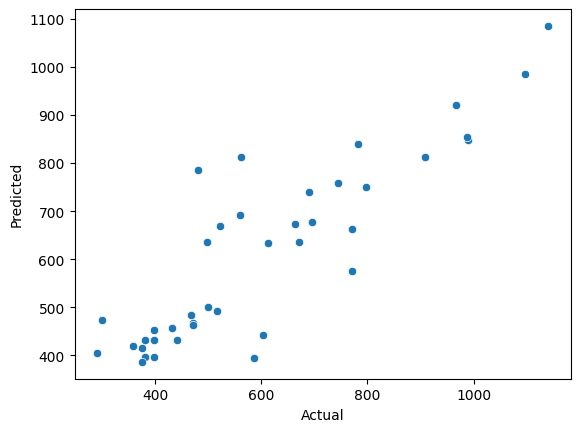

In [155]:
sns.scatterplot(predictions.sample(40),x='Actual',y='Predicted')

In [32]:
import joblib
xgb_pip.fit(X, y)
joblib.dump(xgb_pip, "amount_pipeline_XGB.joblib")
print("Model saved as amount_pipeline.joblib")

Model saved as amount_pipeline.joblib
